In [1]:
import os
import time
import glob
import sys
import argparse
import json
from pathlib import Path

sys.path.append("../..")
#import opensimplex

#from torchvision.utils import save_image

import matplotlib.pyplot as plt
import numpy as np
import csv
import torch
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, Dataset
from monai.utils import set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import autocast
from tqdm import tqdm
import random

import nibabel as nib

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler


from monai.utils import StrEnum
from typing import Union

import pandas as pd

import utils.custom_transforms as custom_transforms
import AnoDDPM.simplex as simplex
import utils.simplex_ddpm as simplex_ddpm
from utils.utils import define_instance

from monai.metrics import compute_iou, DiceMetric

from scipy.ndimage import median_filter
from scipy.ndimage import binary_erosion
from scipy.ndimage import binary_dilation
from scipy.ndimage import label

In [2]:
ROOT_DIR = "/home/fehrdelt/bettik/"

In [25]:
datalist_ano_maps = glob.glob(ROOT_DIR + "datasets/anomaly_maps/exp_1_1/*.nii.gz")

datalist_masks = glob.glob(ROOT_DIR + "datasets/soop_masks_acute/*.nii.gz")

datalist_masks  = [mask for mask in datalist_masks if os.path.basename(mask) in [os.path.basename(ano_map) for ano_map in datalist_ano_maps]]
datalist_ano_maps  = [ano_map for ano_map in datalist_ano_maps if os.path.basename(ano_map) in [os.path.basename(mask) for mask in datalist_masks]]

In [27]:
# sort both lists by basename to keep them aligned
datalist_ano_maps = sorted(datalist_ano_maps, key=os.path.basename)
datalist_masks = sorted(datalist_masks, key=os.path.basename)

# sanity check: basenames must match one-to-one
assert [os.path.basename(a) for a in datalist_ano_maps] == [
    os.path.basename(m) for m in datalist_masks
], "datalist_ano_maps and datalist_masks are not aligned after sorting"

In [28]:
print(len(datalist_ano_maps))
print(len(datalist_masks))

1030
1030


TODO: faire les masques combinés

In [8]:
test_anomaly_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128, 128)),
    ]
)


test_masks_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128, 128)),
        custom_transforms.SetBackgroundToZero()
    ]
)

In [29]:
num_workers = 4
ano_batch_size = 32

test_anomaly_ds = CacheDataset(data=datalist_ano_maps, transform=test_anomaly_transforms)

test_masks_large_ds = CacheDataset(data=datalist_masks, transform=test_masks_transforms)

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1030/1030 [01:25<00:00, 12.02it/s]


In [31]:
# display axial, coronal and sagittal middle slices of the first 4 images of the first batch
loader = DataLoader(test_anomaly_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers)

for i, batch_data in enumerate(loader):
    if i>0:
        break
    unprocessed_ano_batch = batch_data

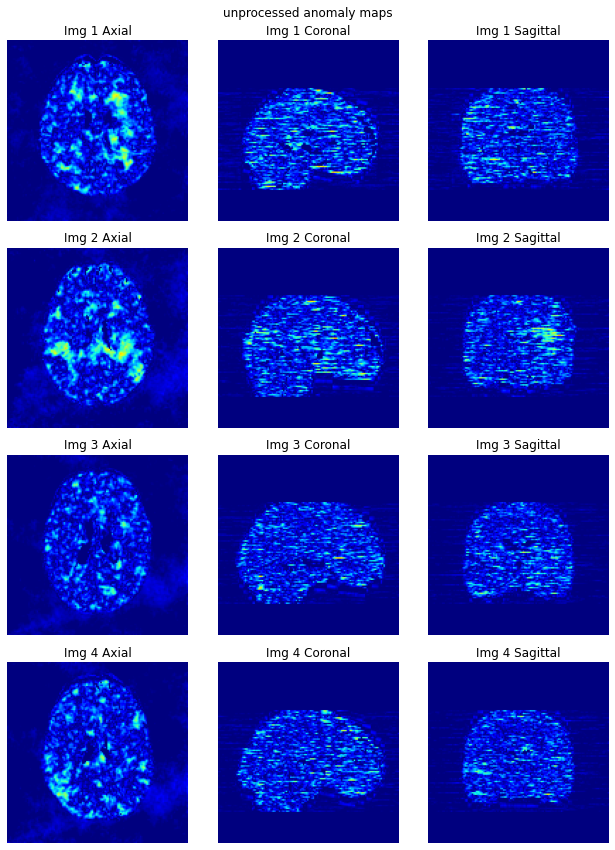

In [44]:

visu_batch = unprocessed_ano_batch[:4]  # first 4 images
if torch.is_tensor(visu_batch):
    imgs = visu_batch
else:
    imgs = torch.as_tensor(visu_batch)

# imgs shape: (N, C, H, W, D)
N, C, H, W, D = imgs.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]  # ensure 2D indexing

for i in range(N):
    vol = imgs[i, 0]  # channel 0
    axial = vol[:, :, d_mid]      # (H, W)
    coronal = vol[h_mid, :, :]    # (W, D)
    sagittal = vol[:, w_mid, :]   # (H, D)

    axes[i, 0].imshow(axial.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 0].set_title(f"Img {i+1} Axial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(coronal.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 1].set_title(f"Img {i+1} Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sagittal.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 2].set_title(f"Img {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle("unprocessed anomaly maps")
plt.tight_layout()

plt.show()

In [41]:

# Apply 3D median filter to unprocessed_ano_batch
# Convert to numpy for scipy processing
ano_batch_np = unprocessed_ano_batch.cpu().numpy()

median_filter_size = 5

# Apply median filter to each image in the batch
filtered_batch = np.zeros_like(ano_batch_np)
for i in range(ano_batch_np.shape[0]):
    filtered_batch[i, 0] = median_filter(ano_batch_np[i, 0], size=median_filter_size)

# Convert back to tensor
filtered_ano_batch = torch.from_numpy(filtered_batch)

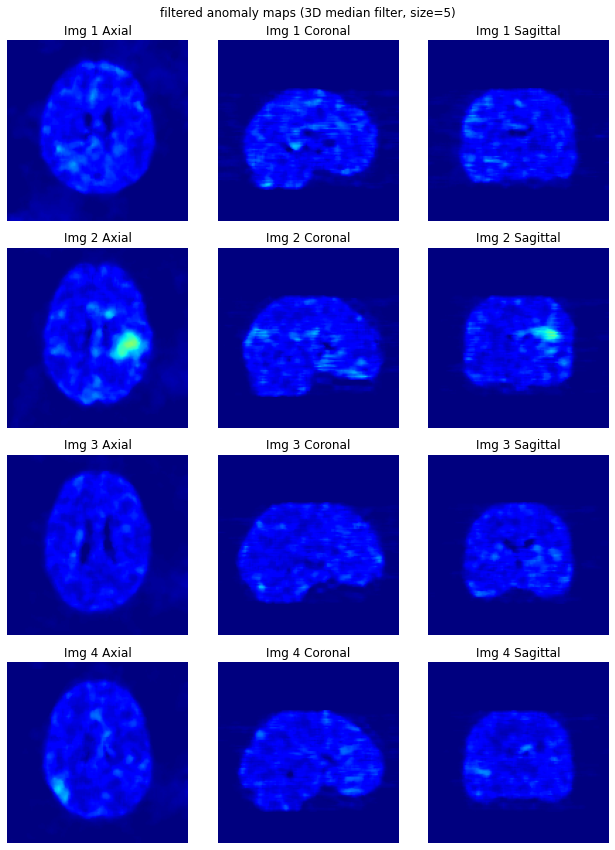

In [43]:

visu_batch = filtered_ano_batch[:4]  # first 4 images
if torch.is_tensor(visu_batch):
    imgs = visu_batch
else:
    imgs = torch.as_tensor(visu_batch)

# imgs shape: (N, C, H, W, D)
N, C, H, W, D = imgs.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]  # ensure 2D indexing

for i in range(N):
    vol = imgs[i, 0]  # channel 0
    axial = vol[:, :, d_mid]      # (H, W)
    coronal = vol[h_mid, :, :]    # (W, D)
    sagittal = vol[:, w_mid, :]   # (H, D)

    axes[i, 0].imshow(axial.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 0].set_title(f"Img {i+1} Axial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(coronal.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 1].set_title(f"Img {i+1} Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sagittal.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 2].set_title(f"Img {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle(f"filtered anomaly maps (3D median filter, size={median_filter_size})")
plt.tight_layout()
plt.show()

In [51]:

# Apply 3D median filter to unprocessed_ano_batch
# Convert to numpy for scipy processing
ano_batch_np = unprocessed_ano_batch.cpu().numpy()

big_median_filter_size = 10

# Apply median filter to each image in the batch
big_filtered_batch = np.zeros_like(ano_batch_np)
for i in range(ano_batch_np.shape[0]):
    big_filtered_batch[i, 0] = median_filter(ano_batch_np[i, 0], size=big_median_filter_size)

# Convert back to tensor
big_filtered_ano_batch = torch.from_numpy(big_filtered_batch)

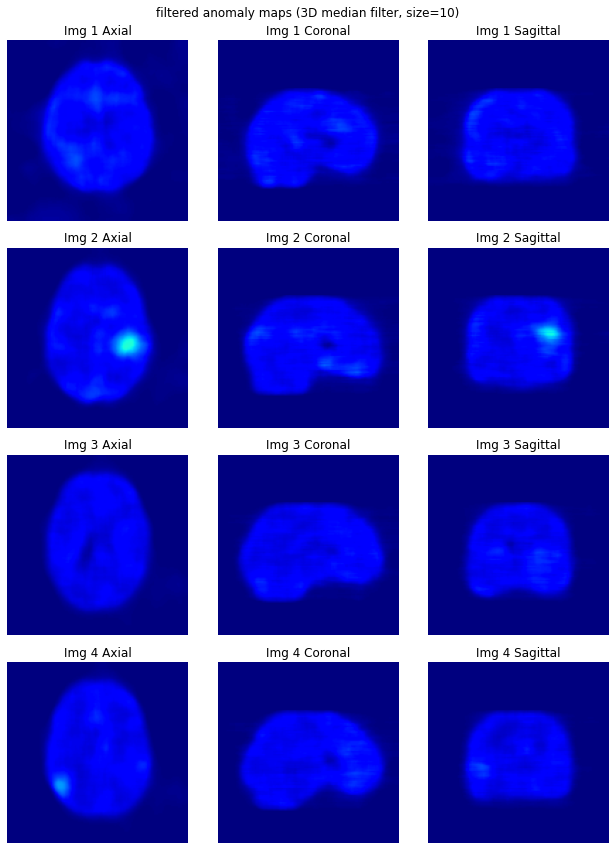

In [52]:

visu_batch = big_filtered_ano_batch[:4]  # first 4 images
if torch.is_tensor(visu_batch):
    imgs = visu_batch
else:
    imgs = torch.as_tensor(visu_batch)

# imgs shape: (N, C, H, W, D)
N, C, H, W, D = imgs.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]  # ensure 2D indexing

for i in range(N):
    vol = imgs[i, 0]  # channel 0
    axial = vol[:, :, d_mid]      # (H, W)
    coronal = vol[h_mid, :, :]    # (W, D)
    sagittal = vol[:, w_mid, :]   # (H, D)

    axes[i, 0].imshow(axial.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 0].set_title(f"Img {i+1} Axial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(coronal.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 1].set_title(f"Img {i+1} Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sagittal.T, cmap="jet", origin="lower", vmin=0, vmax=0.2)
    axes[i, 2].set_title(f"Img {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle(f"filtered anomaly maps (3D median filter, size={big_median_filter_size})")
plt.tight_layout()
plt.show()

In [65]:
threshold = 0.05
thresholded_ano_batch = (filtered_ano_batch > threshold).float()

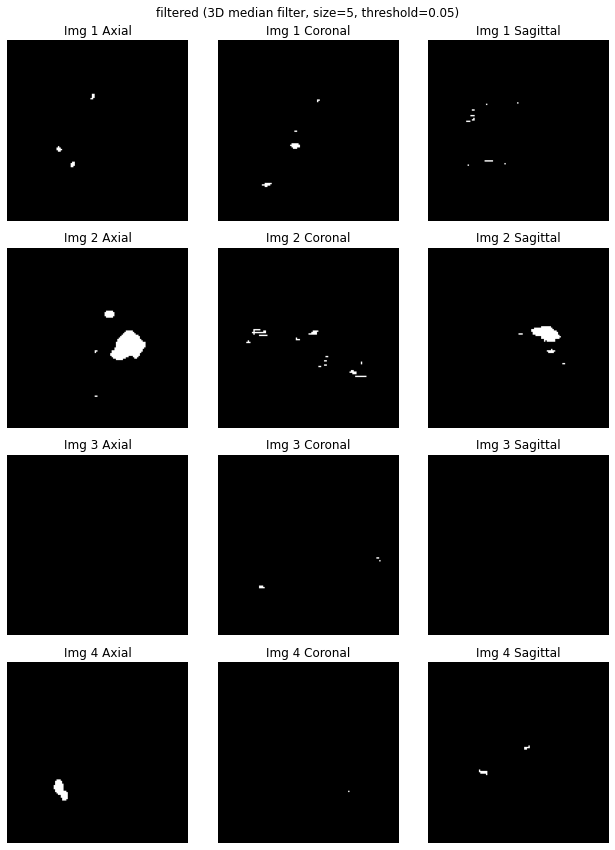

In [66]:

visu_batch = thresholded_ano_batch[:4]  # first 4 images
if torch.is_tensor(visu_batch):
    imgs = visu_batch
else:
    imgs = torch.as_tensor(visu_batch)

# imgs shape: (N, C, H, W, D)
N, C, H, W, D = imgs.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]  # ensure 2D indexing

for i in range(N):
    vol = imgs[i, 0]  # channel 0
    axial = vol[:, :, d_mid]      # (H, W)
    coronal = vol[h_mid, :, :]    # (W, D)
    sagittal = vol[:, w_mid, :]   # (H, D)

    axes[i, 0].imshow(axial.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 0].set_title(f"Img {i+1} Axial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(coronal.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 1].set_title(f"Img {i+1} Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sagittal.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 2].set_title(f"Img {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle(f"filtered (3D median filter, size={median_filter_size}, threshold={threshold})")
plt.tight_layout()
plt.show()

In [67]:

# Perform erosion 3 times on thresholded_ano_batch
erosion_dilation_batch = thresholded_ano_batch.cpu().numpy()

erosion_iterations = 1
dilation_iterations = 1

for i in range(erosion_dilation_batch.shape[0]):
    for _ in range(erosion_iterations):
        erosion_dilation_batch[i, 0] = binary_erosion(erosion_dilation_batch[i, 0])
        
    for _ in range(dilation_iterations):
        erosion_dilation_batch[i, 0] = binary_dilation(erosion_dilation_batch[i, 0], iterations=dilation_iterations)

erosion_dilation_batch = torch.from_numpy(erosion_dilation_batch).float()

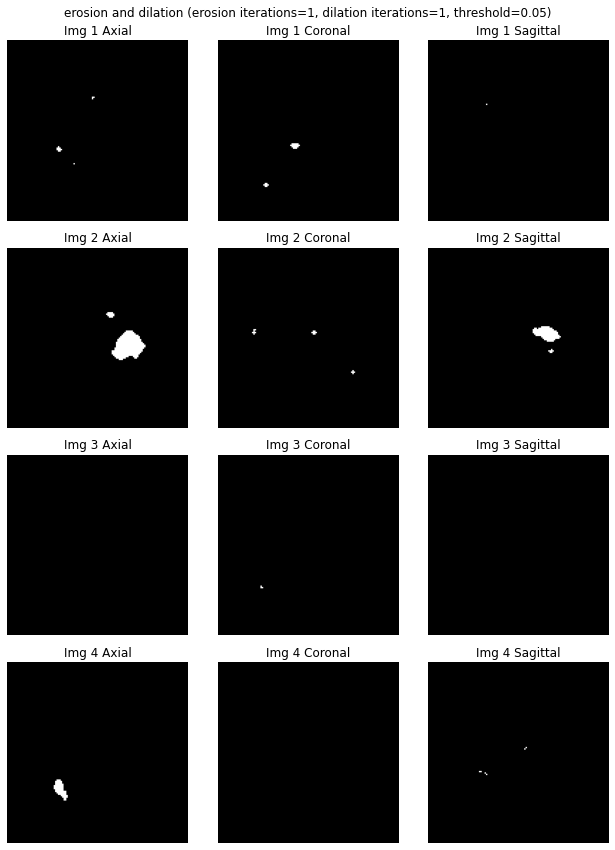

In [68]:

visu_batch = erosion_dilation_batch[:4]  # first 4 images
if torch.is_tensor(visu_batch):
    imgs = visu_batch
else:
    imgs = torch.as_tensor(visu_batch)

# imgs shape: (N, C, H, W, D)
N, C, H, W, D = imgs.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]  # ensure 2D indexing

for i in range(N):
    vol = imgs[i, 0]  # channel 0
    axial = vol[:, :, d_mid]      # (H, W)
    coronal = vol[h_mid, :, :]    # (W, D)
    sagittal = vol[:, w_mid, :]   # (H, D)

    axes[i, 0].imshow(axial.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 0].set_title(f"Img {i+1} Axial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(coronal.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 1].set_title(f"Img {i+1} Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sagittal.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 2].set_title(f"Img {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle(f"erosion and dilation (erosion iterations={erosion_iterations}, dilation iterations={dilation_iterations}, threshold={threshold})")
plt.tight_layout()
plt.show()

In [70]:

# Apply keep largest connected component to erosion_dilation_batch
largest_cc_batch = erosion_dilation_batch.cpu().numpy()

for i in range(largest_cc_batch.shape[0]):
    # Label connected components
    labeled_array, num_features = label(largest_cc_batch[i, 0])
    
    if num_features > 0:
        # Find the largest connected component
        component_sizes = np.bincount(labeled_array.ravel())
        component_sizes[0] = 0  # Exclude background
        largest_component = component_sizes.argmax()
        
        # Keep only the largest component
        largest_cc_batch[i, 0] = (labeled_array == largest_component).astype(float)
    else:
        # No components found, keep as zeros
        largest_cc_batch[i, 0] = np.zeros_like(largest_cc_batch[i, 0])

largest_cc_batch = torch.from_numpy(largest_cc_batch).float()

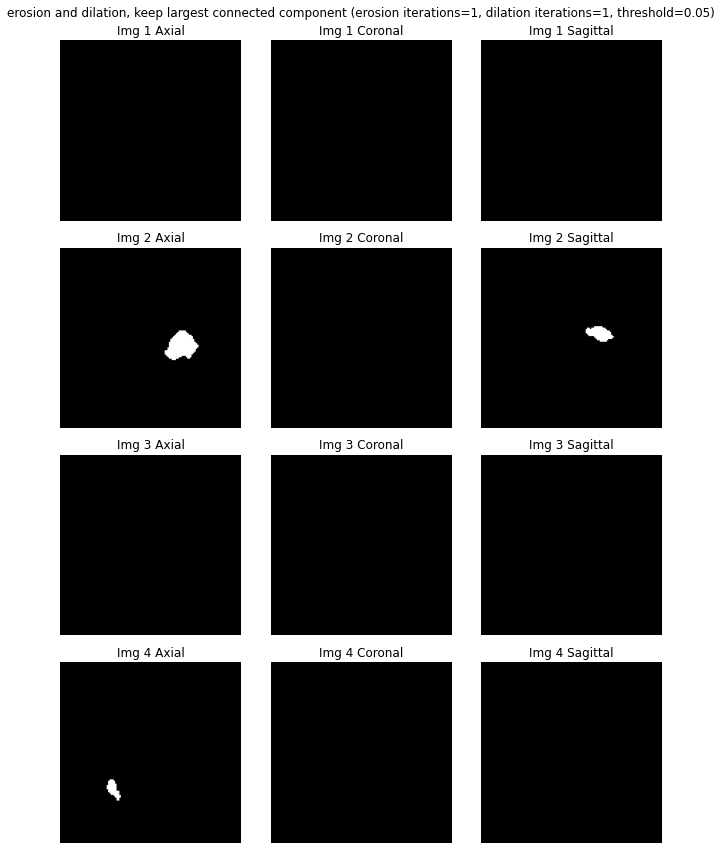

In [72]:

visu_batch = erosion_dilation_batch[:4]  # first 4 images
if torch.is_tensor(visu_batch):
    imgs = visu_batch
else:
    imgs = torch.as_tensor(visu_batch)

# imgs shape: (N, C, H, W, D)
N, C, H, W, D = imgs.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]  # ensure 2D indexing

for i in range(N):
    vol = imgs[i, 0]  # channel 0
    axial = vol[:, :, d_mid]      # (H, W)
    coronal = vol[h_mid, :, :]    # (W, D)
    sagittal = vol[:, w_mid, :]   # (H, D)

    axes[i, 0].imshow(axial.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 0].set_title(f"Img {i+1} Axial")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(coronal.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 1].set_title(f"Img {i+1} Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sagittal.T, cmap="gray", origin="lower", vmin=0, vmax=0.2)
    axes[i, 2].set_title(f"Img {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle(f"erosion and dilation, keep largest connected component (erosion iterations={erosion_iterations}, dilation iterations={dilation_iterations}, threshold={threshold})")
plt.tight_layout()
plt.show()

--------------------

In [30]:
masks_folder = ROOT_DIR+"datasets/final_soop_dataset_small/masks_acute_registered/"

In [31]:
filelist = glob.glob(masks_folder+"/*.nii.gz")
large_group = ['sub-1010', 'sub-1013', 'sub-1015', 'sub-1032', 'sub-1035', 'sub-1039', 'sub-1041', 'sub-1045', 'sub-1046', 'sub-1071', 'sub-1073', 'sub-1086', 'sub-1102', 'sub-1107', 'sub-1115', 'sub-113', 'sub-114', 'sub-1149', 'sub-1150', 'sub-116', 'sub-1164', 'sub-1165', 'sub-118', 'sub-1200', 'sub-1204', 'sub-1209', 'sub-1213', 'sub-1215', 'sub-1223', 'sub-1227', 'sub-1232', 'sub-1246', 'sub-1258', 'sub-127', 'sub-1280', 'sub-1282', 'sub-1283', 'sub-1285', 'sub-1292', 'sub-1305', 'sub-1306', 'sub-1309', 'sub-1312', 'sub-1314', 'sub-1320', 'sub-1323', 'sub-135', 'sub-1354', 'sub-1355', 'sub-1358', 'sub-1364', 'sub-1366', 'sub-1369', 'sub-1373', 'sub-1379', 'sub-1382', 'sub-1386', 'sub-1395', 'sub-1409', 'sub-1410', 'sub-1413', 'sub-1422', 'sub-1432', 'sub-1445', 'sub-1447', 'sub-1475', 'sub-1478', 'sub-1480', 'sub-1483', 'sub-1485', 'sub-1488', 'sub-1507', 'sub-1508', 'sub-1511', 'sub-1517', 'sub-1552', 'sub-1554', 'sub-1555', 'sub-1569', 'sub-1598', 'sub-1612', 'sub-1634', 'sub-1637', 'sub-1656', 'sub-1670', 'sub-1677', 'sub-1719', 'sub-1725', 'sub-1727', 'sub-1736', 'sub-174', 'sub-177', 'sub-185', 'sub-190', 'sub-196', 'sub-198', 'sub-2', 'sub-221', 'sub-235', 'sub-241', 'sub-247', 'sub-249', 'sub-260', 'sub-262', 'sub-264', 'sub-278', 'sub-284', 'sub-294', 'sub-3', 'sub-303', 'sub-314', 'sub-321', 'sub-326', 'sub-335', 'sub-338', 'sub-339', 'sub-341', 'sub-343', 'sub-345', 'sub-359', 'sub-360', 'sub-366', 'sub-370', 'sub-374', 'sub-386', 'sub-398', 'sub-400', 'sub-401', 'sub-412', 'sub-42', 'sub-422', 'sub-432', 'sub-433', 'sub-443', 'sub-446', 'sub-447', 'sub-457', 'sub-463', 'sub-464', 'sub-466', 'sub-47', 'sub-494', 'sub-498', 'sub-501', 'sub-505', 'sub-512', 'sub-517', 'sub-521', 'sub-523', 'sub-525', 'sub-529', 'sub-53', 'sub-530', 'sub-539', 'sub-543', 'sub-56', 'sub-563', 'sub-572', 'sub-613', 'sub-620', 'sub-631', 'sub-634', 'sub-638', 'sub-651', 'sub-652', 'sub-661', 'sub-682', 'sub-692', 'sub-694', 'sub-698', 'sub-699', 'sub-707', 'sub-719', 'sub-723', 'sub-724', 'sub-751', 'sub-754', 'sub-760', 'sub-761', 'sub-768', 'sub-776', 'sub-789', 'sub-79', 'sub-791', 'sub-8', 'sub-803', 'sub-806', 'sub-82', 'sub-823', 'sub-826', 'sub-843', 'sub-844', 'sub-845', 'sub-858', 'sub-861', 'sub-865', 'sub-866', 'sub-873', 'sub-877', 'sub-881', 'sub-896', 'sub-917', 'sub-937', 'sub-939', 'sub-942', 'sub-946', 'sub-95', 'sub-952', 'sub-959', 'sub-960', 'sub-968', 'sub-990']

In [32]:
large_group_filelist = [os.path.join(masks_folder, f"{subj_id}.nii.gz") for subj_id in large_group]

In [33]:
print(len(large_group_filelist))

212


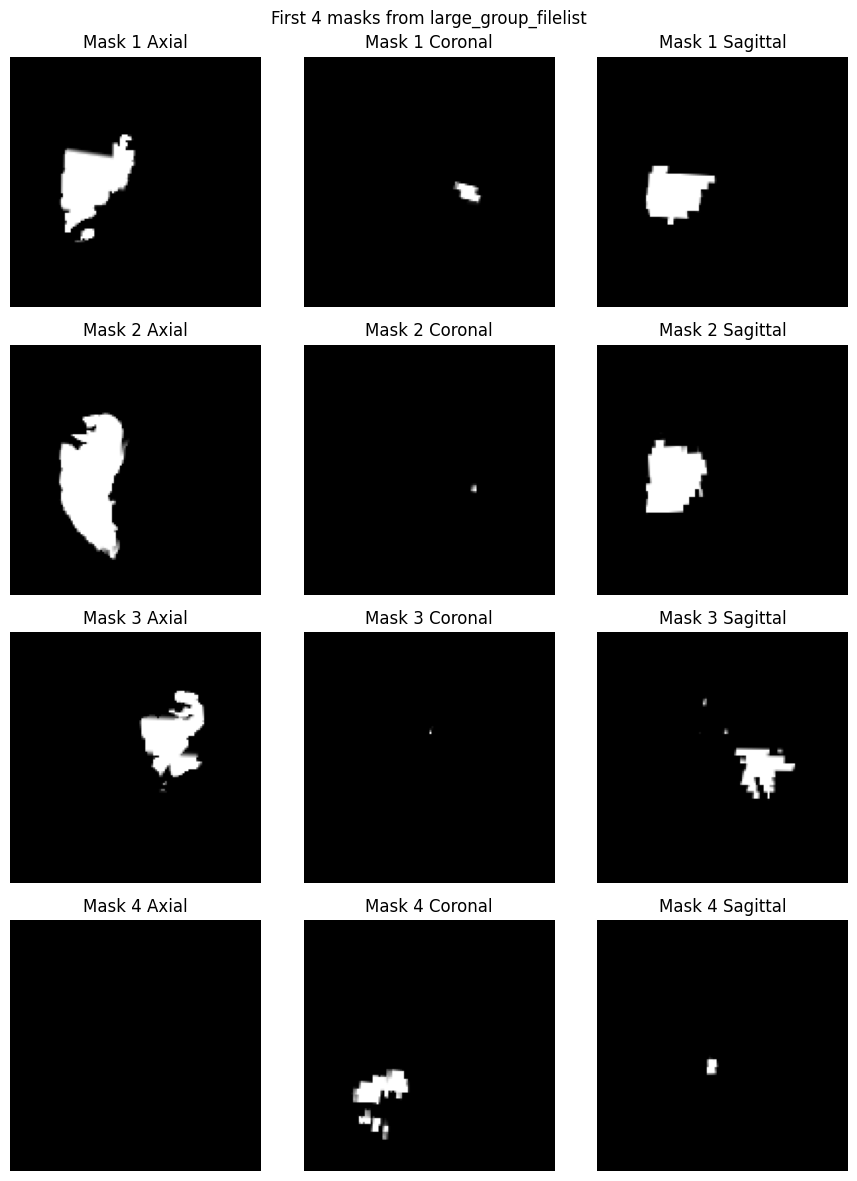

In [38]:
# Load and display the first 4 masks from large_group_filelist
first_4_masks = large_group_filelist[:4]

# Load the masks using the transforms
loaded_masks = []
for mask_path in first_4_masks:
    mask = test_masks_transforms(mask_path)
    loaded_masks.append(mask)

# Stack into a single tensor
masks_tensor = torch.stack(loaded_masks)

# Display the masks
N, C, H, W, D = masks_tensor.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]

for i in range(N):
    vol = masks_tensor[i, 0]
    axial = vol[:, :, d_mid]
    coronal = vol[h_mid, :, :]
    sagittal = vol[:, w_mid, :]
    
    axes[i, 0].imshow(axial.T, cmap="gray", origin="lower")
    axes[i, 0].set_title(f"Mask {i+1} Axial")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(coronal.T, cmap="gray", origin="lower")
    axes[i, 1].set_title(f"Mask {i+1} Coronal")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(sagittal.T, cmap="gray", origin="lower")
    axes[i, 2].set_title(f"Mask {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle("First 4 masks from large_group_filelist")
plt.tight_layout()
plt.show()

In [39]:
# Apply 4 steps of binary erosion followed by 4 steps of binary dilation to the loaded masks
processed_masks = masks_tensor.cpu().numpy().copy()

erosion_steps = 6
dilation_steps = 6

for i in range(processed_masks.shape[0]):
    # Apply erosion
    for _ in range(erosion_steps):
        processed_masks[i, 0] = binary_erosion(processed_masks[i, 0])
    
    # Apply dilation
    for _ in range(dilation_steps):
        processed_masks[i, 0] = binary_dilation(processed_masks[i, 0])

processed_masks_tensor = torch.from_numpy(processed_masks).float()


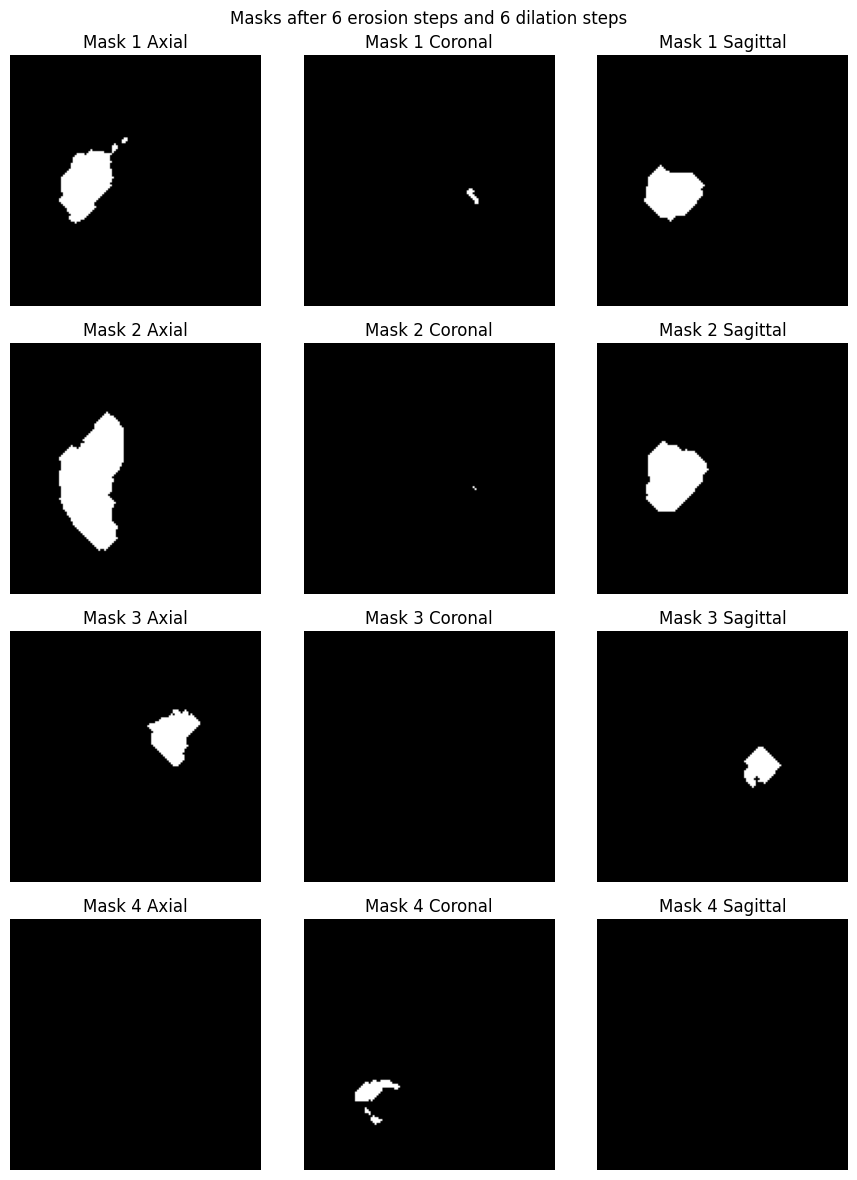

In [40]:

# Display the processed masks
N, C, H, W, D = processed_masks_tensor.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]

for i in range(N):
    vol = processed_masks_tensor[i, 0]
    axial = vol[:, :, d_mid]
    coronal = vol[h_mid, :, :]
    sagittal = vol[:, w_mid, :]
    
    axes[i, 0].imshow(axial.T, cmap="gray", origin="lower")
    axes[i, 0].set_title(f"Mask {i+1} Axial")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(coronal.T, cmap="gray", origin="lower")
    axes[i, 1].set_title(f"Mask {i+1} Coronal")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(sagittal.T, cmap="gray", origin="lower")
    axes[i, 2].set_title(f"Mask {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle(f"Masks after {erosion_steps} erosion steps and {dilation_steps} dilation steps")
plt.tight_layout()
plt.show()

In [41]:
from ipywidgets import interact, IntSlider

def display_axial_slice(slice_idx):
    N, C, H, W, D = processed_masks_tensor.shape
    
    fig, axes = plt.subplots(2, N, figsize=(4 * N, 8))
    if N == 1:
        axes = axes.reshape(2, 1)
    
    for i in range(N):
        # Original masks (without erosion/dilation)
        vol_orig = masks_tensor[i, 0]
        axial_orig = vol_orig[:, :, slice_idx]
        
        axes[0, i].imshow(axial_orig.T, cmap="gray", origin="lower")
        axes[0, i].set_title(f"Original Mask {i+1} - Slice {slice_idx}")
        axes[0, i].axis("off")
        
        # Processed masks (with erosion/dilation)
        vol_proc = processed_masks_tensor[i, 0]
        axial_proc = vol_proc[:, :, slice_idx]
        
        axes[1, i].imshow(axial_proc.T, cmap="gray", origin="lower")
        axes[1, i].set_title(f"Processed Mask {i+1} - Slice {slice_idx}")
        axes[1, i].axis("off")
    
    plt.suptitle(f"Axial slice {slice_idx}/{D-1}")
    plt.tight_layout()
    plt.show()

# Create interactive slider
interact(display_axial_slice, 
         slice_idx=IntSlider(min=0, max=processed_masks_tensor.shape[-1]-1, step=1, value=64))


interactive(children=(IntSlider(value=64, description='slice_idx', max=127), Output()), _dom_classes=('widget-…

<function __main__.display_axial_slice(slice_idx)>

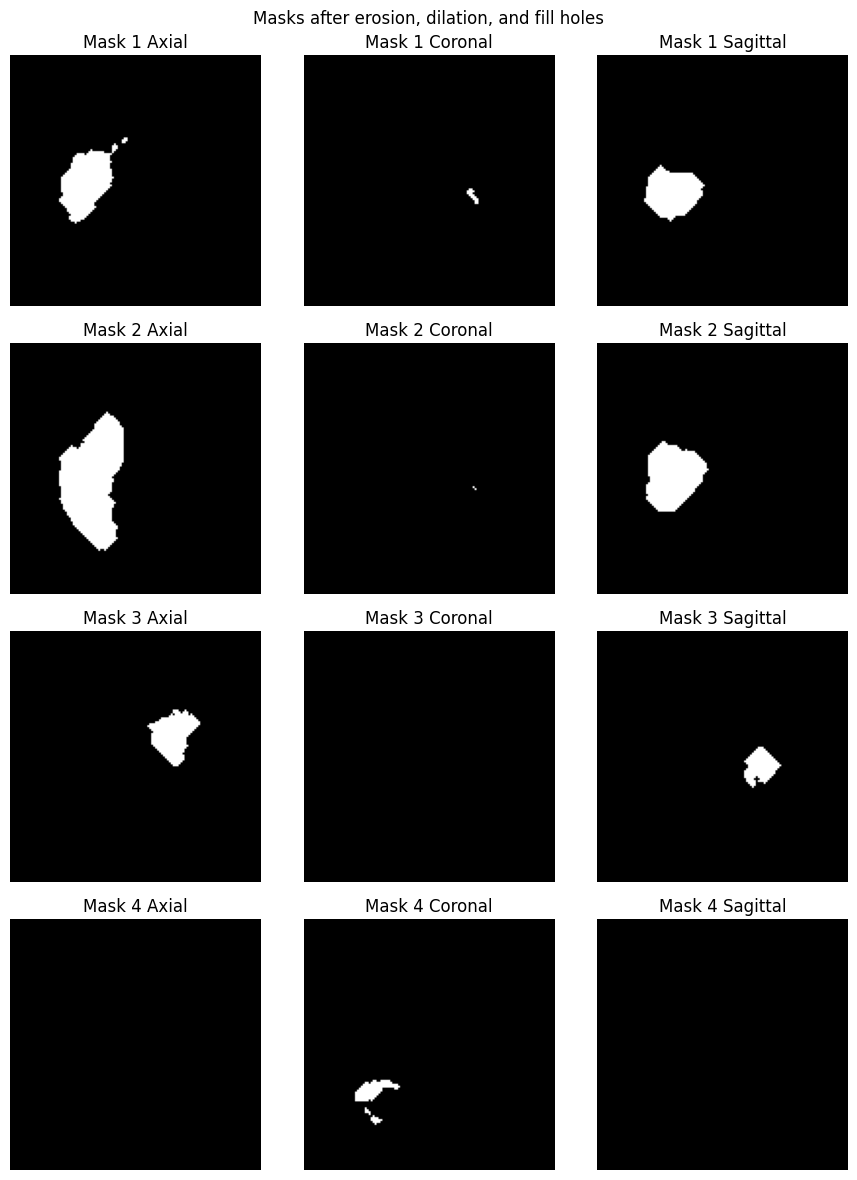

In [42]:
from scipy.ndimage import binary_fill_holes

# Apply binary_fill_holes to the processed masks
filled_masks = processed_masks_tensor.cpu().numpy().copy()

for i in range(filled_masks.shape[0]):
    filled_masks[i, 0] = binary_fill_holes(filled_masks[i, 0])

filled_masks_tensor = torch.from_numpy(filled_masks).float()

# Display the filled masks
N, C, H, W, D = filled_masks_tensor.shape
h_mid, w_mid, d_mid = H // 2, W // 2, D // 2

fig, axes = plt.subplots(N, 3, figsize=(9, 3 * N))
if N == 1:
    axes = axes[None, :]

for i in range(N):
    vol = filled_masks_tensor[i, 0]
    axial = vol[:, :, d_mid]
    coronal = vol[h_mid, :, :]
    sagittal = vol[:, w_mid, :]
    
    axes[i, 0].imshow(axial.T, cmap="gray", origin="lower")
    axes[i, 0].set_title(f"Mask {i+1} Axial")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(coronal.T, cmap="gray", origin="lower")
    axes[i, 1].set_title(f"Mask {i+1} Coronal")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(sagittal.T, cmap="gray", origin="lower")
    axes[i, 2].set_title(f"Mask {i+1} Sagittal")
    axes[i, 2].axis("off")

plt.suptitle(f"Masks after erosion, dilation, and fill holes")
plt.tight_layout()
plt.show()